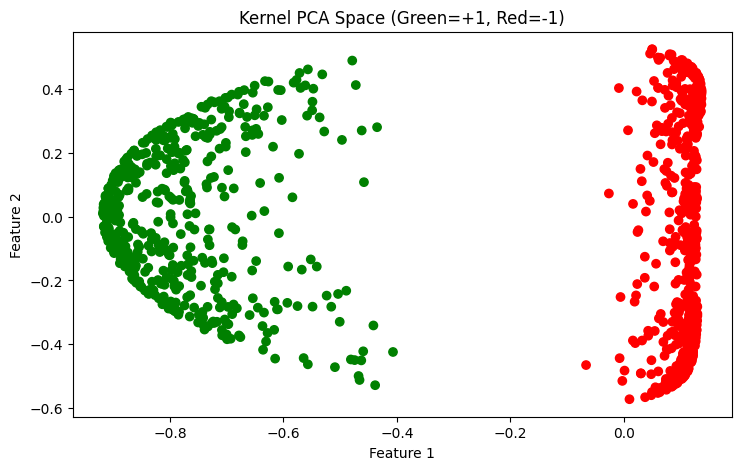

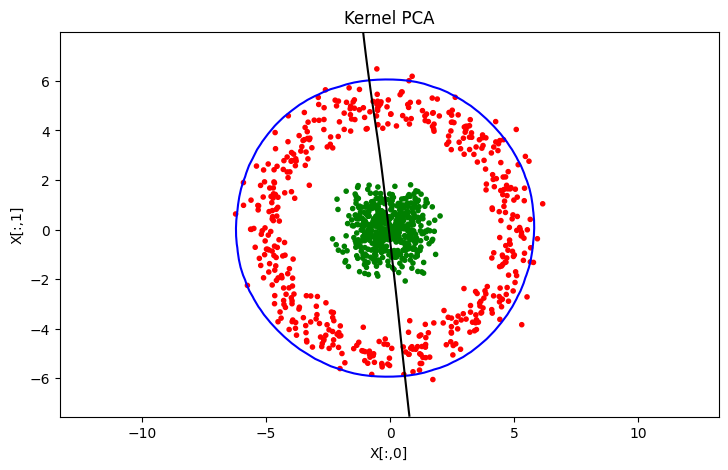

In [16]:
import numpy as np
from matplotlib.pyplot import contour
from matplotlib.pyplot import scatter
import matplotlib.pyplot as plt

def gaussian_gram_matrix(X, sigma=2):
    sq_norms = np.sum(X**2, axis=1)
    dot_products = np.dot(X, X.T)
    sq_dists = sq_norms[:, np.newaxis] + sq_norms[np.newaxis, :] - 2 * dot_products
    gamma = 1.0 / (2 * sigma**2)
    return np.exp(-gamma * sq_dists)

def kernel_PCA(k, X, p):
    n = X.shape[0]
    wons = (1/n) * np.ones((n, n))
    Kc = k - wons @ k - k @ wons + wons @ k @ wons
    eigenvalues, eigenvectors = np.linalg.eigh(Kc)
    eigenvalues = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]   
    scaledvectors = np.zeros((n, n))
    # Avoid division by zero for very small eigenvalues
    for i in range(n):
        if eigenvalues[i] > 1e-10:
            scaledvectors[:, i] = eigenvectors[:, i] / eigenvalues[i]**(1/2)
    return scaledvectors

# Create data
n = 1000
x1 = np.cos(2*np.pi*np.random.uniform(0, 1, n//2)) + np.random.normal(0, .5, n//2)
x2 = np.sin(2*np.pi*np.random.uniform(0, 1, n//2)) + np.random.normal(0, .5, n//2)
theta = np.linspace(0, 2*np.pi, n//2)
xx1 = 5*np.cos(theta) + .5*np.random.normal(0, 1, n//2)
xx2 = 5*np.sin(theta) + .5*np.random.normal(0, 1, n//2)

X = np.vstack([np.column_stack([x1, x2]), np.column_stack([xx1, xx2])])

# Create labels: +1 for first n//2 (green), -1 for next n//2 (red)
colors = ['green'] * (n//2) + ['red'] * (n//2)

K = gaussian_gram_matrix(X)
scaledvectors = K @ kernel_PCA(K, X, 2)
PCA1 = scaledvectors[:, 0]
PCA2 = scaledvectors[:, 1]

# First Plot: PCA Space
plt.figure(figsize=(8.5, 5))
plt.scatter(PCA1, PCA2, c=colors)
plt.title("Kernel PCA Space (Green=+1, Red=-1)")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

# See how the score contours look
x_min, x_max = X[:, 0].min() - 1.5, X[:, 0].max() + 1.5
y_min, y_max = X[:, 1].min() - 1.5, X[:, 1].max() + 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50), np.linspace(y_min, y_max, 50))
grid_points = np.c_[xx.ravel(), yy.ravel()]

def project_grid(grid, X_train, alpha_vec, sigma=2.0):
    sq_norms_g = np.sum(grid**2, axis=1)
    sq_norms_x = np.sum(X_train**2, axis=1)
    dot_px = np.dot(grid, X_train.T)
    dist = sq_norms_g[:, np.newaxis] + sq_norms_x[np.newaxis, :] - 2 * dot_px
    K_grid = np.exp(-dist / (2 * sigma**2))
    return K_grid @ alpha_vec

Z1 = project_grid(grid_points, X, scaledvectors[:, 0]).reshape(xx.shape)
Z2 = project_grid(grid_points, X, scaledvectors[:, 1]).reshape(xx.shape)

# Second Plot: Original Space with Contours
plt.figure(figsize=(8.5, 5))
plt.scatter(X[:, 0], X[:, 1], c=colors, label='Original Data', marker='.')

plot1 = plt.contour(xx, yy, Z1, colors='blue', levels=[0], alpha=1) 
plt.contour(xx, yy, Z2, colors='black', levels=[0], alpha=1)  
plt.title("Kernel PCA")
plt.xlabel("X[:,0]")
plt.ylabel("X[:,1]")
plt.axis('equal')
plt.show()